In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("iris_for_decision_tree.csv")

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [62]:
X = df.drop(columns=['species'])
y = df['species'] 
y_numeric = y.astype('category').cat.codes

In [63]:
X.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

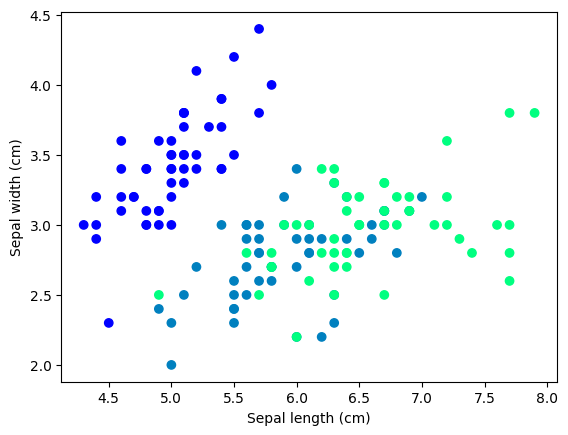

In [64]:
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y_numeric, cmap='winter')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
print("Acc (train):", clf.score(X_train,y_train))
print("Acc (test):", clf.score(X_test,y_test))

Acc (train): 1.0
Acc (test): 0.9333333333333333


In [14]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [15]:
y_pred = clf.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [20]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,10,0,0
1,0,9,1
2,0,1,9


In [23]:
from sklearn import tree

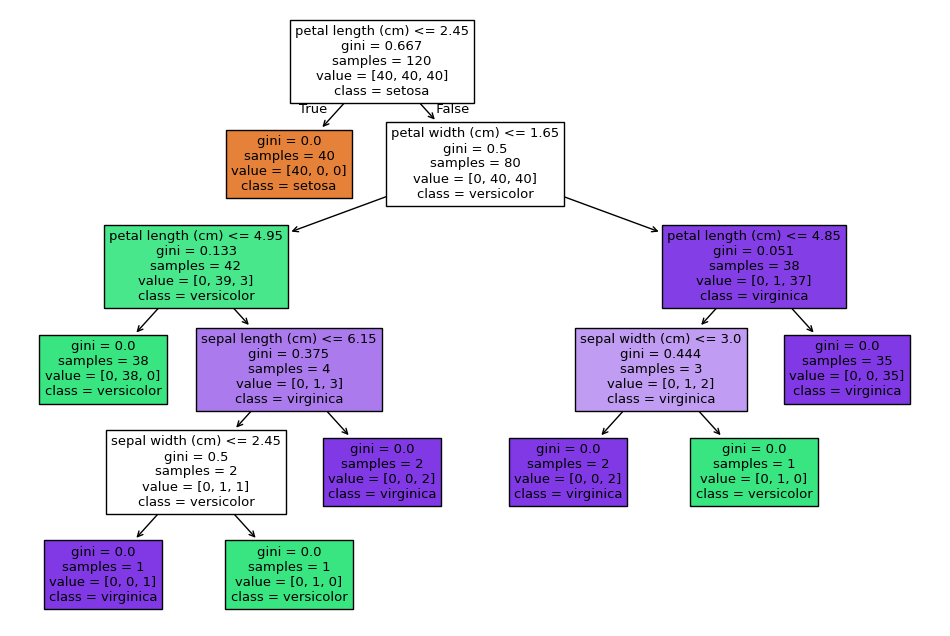

In [24]:
plt.figure(figsize=(12,8))
tree.plot_tree(clf,feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show()

petal length (cm)    0.558568
petal width (cm)     0.406015
sepal width (cm)     0.029167
sepal length (cm)    0.006250
dtype: float64


<Axes: >

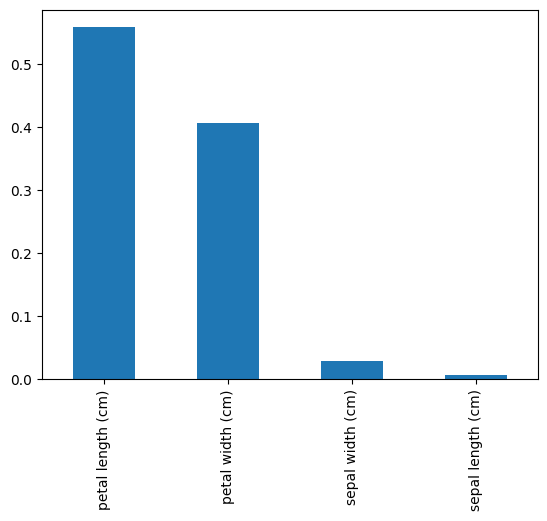

In [25]:
import pandas as pd
fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi)
fi.plot.bar()


In [51]:
clf2 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42, criterion='entropy')
clf2.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
print("Acc (train):", clf2.score(X_train,y_train))
print("Acc (test):", clf2.score(X_test,y_test))

Acc (train): 0.9666666666666667
Acc (test): 0.9333333333333333


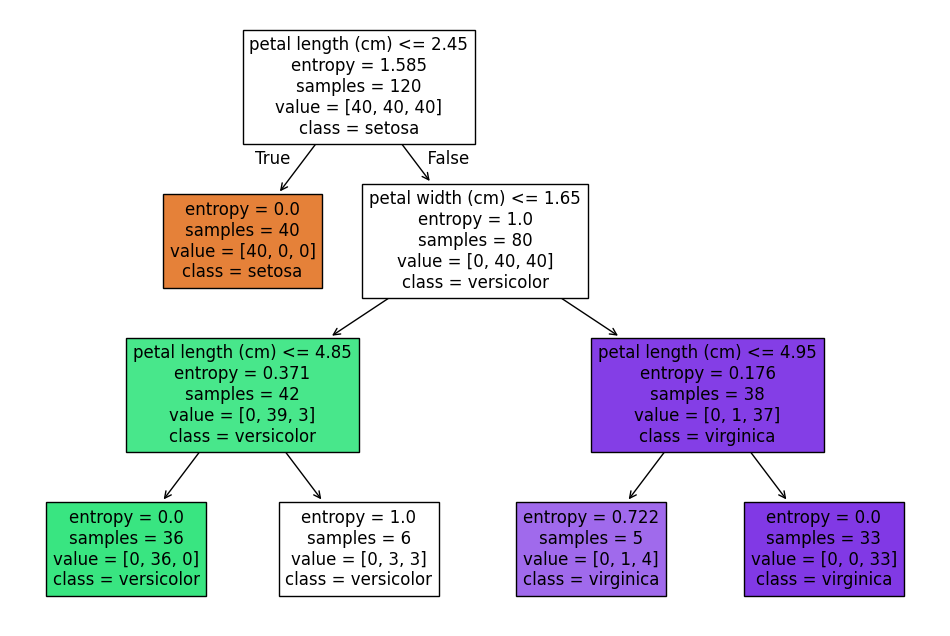

In [53]:
plt.figure(figsize=(12,8))
tree.plot_tree(clf2,feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV

In [56]:
params_grid = {
    'max_depth': [2,3,4,5,None],
    'min_samples_leaf': [1,2,3,4,5],
    'criterion': ['gini','entropy']
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params_grid, cv=5, n_jobs=-1)
grid.fit(X_train,y_train)
print("Best params:", grid.best_params_)
best = grid.best_estimator_
print("Test accuracy with best estimator:", best.score(X_test,y_test))

Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Test accuracy with best estimator: 0.9333333333333333
